# Método de Bisección

Implementación y aplicación del **método de bisección** para aproximar raíces de ecuaciones no lineales utilizando Python.

Este notebook reúne varios ejercicios desarrollados durante el estudio de **Análisis Numérico**, reorganizados y documentados para mostrar el método, su implementación y algunas aplicaciones.

### Objetivos

- Comprender el fundamento del método de bisección.
- Implementar un algoritmo reutilizable en Python.
- Aproximar raíces con una tolerancia definida.
- Aplicar el método a problemas matemáticos y de ingeniería.

**Tecnologías:** Python · NumPy · Matplotlib

## 1. Fundamento del método

El método de bisección permite aproximar una raíz de una función continua $f(x)$ dentro de un intervalo $[a,b]$.

Si se cumple que $f(a)\cdot f(b)<0$, entonces, por el **Teorema de Bolzano**, existe al menos una raíz en el intervalo.

En cada iteración se calcula el punto medio:

$c=\frac{a+b}{2}$

y se conserva el subintervalo en el que continúa existiendo un cambio de signo. El proceso se repite hasta alcanzar la tolerancia deseada.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def MetodoBiseccion(FuncionObjetivo, ExtremoIzquierdo, ExtremoDerecho, Tolerancia):
    # Verificamos si la función cumple el Teorema de Bolzano en el intervalo
    if (FuncionObjetivo(ExtremoIzquierdo) * FuncionObjetivo(ExtremoDerecho) > 0):
        print("La función no cumple el teorema en el intervalo, busque otro [a,b]")
    else:
        print("Buscando el cero f(x) = 0...")
        i = 0

        # Mientras la longitud del intervalo sea mayor que la tolerancia
        while (abs(ExtremoDerecho - ExtremoIzquierdo) > Tolerancia):
            PuntoMedio = (ExtremoIzquierdo + ExtremoDerecho) / 2
            i += 1

            # Si el valor en el punto medio es suficientemente pequeño,
            # devolvemos la solución
            if abs(FuncionObjetivo(PuntoMedio)) < Tolerancia:
                print("Punto medio:", PuntoMedio, "Iteraciones:", i)
                return PuntoMedio, i
            # Si el cambio de signo se encuentra en el intervalo izquierdo
            if (FuncionObjetivo(ExtremoIzquierdo) * FuncionObjetivo(PuntoMedio) < 0):
                ExtremoDerecho = PuntoMedio
            else:
                ExtremoIzquierdo = PuntoMedio

        return PuntoMedio, i

## 2. Verificación básica

Como prueba inicial se busca la raíz positiva de $f(x)=x^2-4$, en el intervalo $[1,3]$. La raíz exacta esperada es $x=2$.

In [2]:
# Verificación básica del método

FuncionObjetivo = lambda valor_x: valor_x**2 - 4
ExtremoIzquierdo = 1
ExtremoDerecho = 3
Tolerancia = 1e-8

MetodoBiseccion(
    FuncionObjetivo,
    ExtremoIzquierdo,
    ExtremoDerecho,
    Tolerancia
)

Buscando el cero f(x) = 0...
Punto medio: 2.0 Iteraciones: 1


(2.0, 1)

## 3. Aplicación 1 — Ecuación no lineal

Sea la función: $f(x)=3^{-x}-x$

Se desea encontrar una aproximación de $\alpha$ tal que: $f(\alpha)=0$ en el intervalo $[0,1]$. La función es continua y se cumple que: $f(0)=1$ y $f(1)=-\frac{2}{3}$ Como existe un cambio de signo entre los extremos del intervalo, el **Teorema de Bolzano** garantiza que existe al menos una raíz en $[0,1]$.

In [3]:
FuncionObjetivo = lambda valor_x: 3**(-valor_x) - valor_x

ExtremoIzquierdo = 0
ExtremoDerecho = 1
Tolerancia = 1e-8

Raiz, Iteraciones = MetodoBiseccion(
    FuncionObjetivo,
    ExtremoIzquierdo,
    ExtremoDerecho,
    Tolerancia
)

Residuo = abs(FuncionObjetivo(Raiz))

print(f"Raíz aproximada α: {Raiz:.10f}")
print(f"Iteraciones: {Iteraciones}")
print(f"Residuo |f(α)|: {Residuo:.2e}")

Buscando el cero f(x) = 0...
Punto medio: 0.5478086173534393 Iteraciones: 25
Raíz aproximada α: 0.5478086174
Iteraciones: 25
Residuo |f(α)|: 6.89e-09


## 4. Aplicación 2 — Movimiento sobre un plano inclinado

Una partícula parte del reposo sobre un plano inclinado cuyo ángulo cambia a una tasa constante:

$\frac{d\theta}{dt}=\omega<0$

La posición después de $t$ segundos está dada por:

$$
x(t)=
-\frac{g}{2\omega^2}
\left(
\frac{e^{\omega t}-e^{-\omega t}}{2}
-\sin(\omega t)
\right)
$$

Si la partícula se desplaza $1.7$ pies en $1$ segundo y $g=32.17\ \text{pies/s}^2$, se desea aproximar el valor de $\omega$.

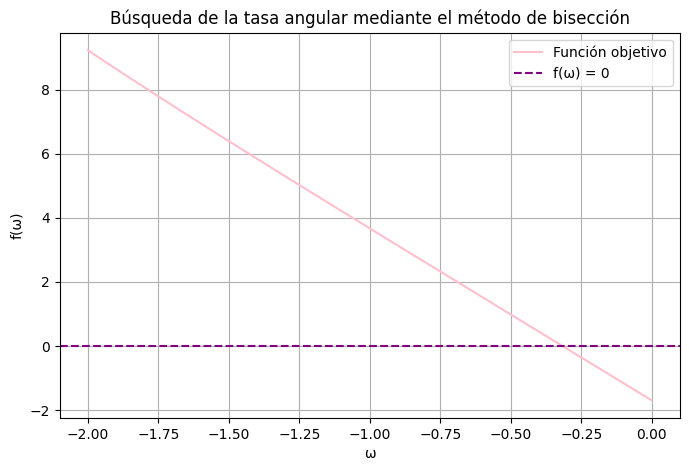

La tasa ω a la que varía el ángulo θ es:
Buscando el cero f(x) = 0...
Punto medio: -0.31706177443265915 Iteraciones: 25


(-0.31706177443265915, 25)

In [4]:
# Datos del problema
x = 1.7
t = 1
g = 32.17
Tolerancia = 1e-8

# Función objetivo
FuncionObjetivo = lambda w: (
    (-g / (2 * w**2))
    * ((np.exp(w * t) - np.exp(-w * t)) / 2 - np.sin(w * t))
    - x
)

# Intervalo determinado a partir de la gráfica
ExtremoIzquierdo = -0.5
ExtremoDerecho = -0.25

# Valores de ω utilizados para visualizar el comportamiento de la función
array_w = np.linspace(-2, -1e-3, 100)

# Gráfica de la función
plt.figure(figsize=(8, 5))
plt.plot(
    array_w,
    FuncionObjetivo(array_w),
    color="pink",
    label="Función objetivo"
)

# Línea horizontal y = 0 para identificar gráficamente la raíz
plt.axhline(
    0,
    linestyle="--",
    color="purple",
    label="f(ω) = 0"
)

plt.xlabel("ω")
plt.ylabel("f(ω)")
plt.title("Búsqueda de la tasa angular mediante el método de bisección")
plt.grid()
plt.legend()
plt.show()

# Aplicación del método de bisección
print("La tasa ω a la que varía el ángulo θ es:")

MetodoBiseccion(
    FuncionObjetivo,
    ExtremoIzquierdo,
    ExtremoDerecho,
    Tolerancia
)

## 5. Aplicación 3 — Trayectoria de un proyectil

La trayectoria de una pelota puede modelarse mediante:

$y = x\tan(\theta_0) - \frac{g\,x^2}{2v_0^2\cos^2(\theta_0)} + y_0$

Se conocen los siguientes datos:

- $v_0 = 20\ \text{m/s}$
- $x = 35\ \text{m}$
- $y_0 = 2\ \text{m}$
- $y = 1\ \text{m}$
- $g = 9.8\ \text{m/s}^2$

El objetivo es determinar el ángulo inicial $\theta_0$ que permite que la pelota alcance la posición indicada y expresar el resultado en grados.

In [5]:
# Datos del problema
x = 35
y0 = 2
y = 1
v0 = 20
g = 9.8
Tolerancia = 1e-8

# Función objetivo
FuncionObjetivo1 = lambda theta: (
    (x * np.tan(theta))
    - (g * x**2) / (2 * v0**2 * (np.cos(theta))**2)
    + y0
    - y
)

# Intervalo de búsqueda
ExtremoIzquierdo = 0
ExtremoDerecho = np.pi / 4

# Aplicación del método de bisección
Theta, Iteraciones = MetodoBiseccion(
    FuncionObjetivo1,
    ExtremoIzquierdo,
    ExtremoDerecho,
    Tolerancia
)

# Conversión del resultado de radianes a grados
AnguloGrados = np.degrees(Theta)

# Verificación del resultado
Residuo = abs(FuncionObjetivo1(Theta))

print(f"Ángulo inicial θ₀: {Theta:.10f} rad")
print(f"Ángulo inicial θ₀: {AnguloGrados:.6f}°")
print(f"Iteraciones: {Iteraciones}")
print(f"Residuo |f(θ₀)|: {Residuo:.2e}")

Buscando el cero f(x) = 0...
Ángulo inicial θ₀: 0.4740108013 rad
Ángulo inicial θ₀: 27.158818°
Iteraciones: 27
Residuo |f(θ₀)|: 1.11e-07


## 6. Aplicación 4 — Profundidad de agua en un abrevadero

Un abrevadero de longitud $L$ tiene una sección transversal semicircular de radio $r$.

El volumen del agua está dado por:

$V = L\left[\frac{1}{2}\pi r^2 - r^2\sin^{-1}\left(\frac{h}{r}\right) - h\sqrt{r^2-h^2}\right]$

Se conocen los siguientes datos:

- $L = 10\ \text{pies}$
- $r = 4\ \text{pies}$
- $V = 10\ \text{pies}^3$

El objetivo es aproximar el valor de $h$, que representa la distancia desde la superficie del agua hasta la parte superior del semicírculo.

Una vez obtenido $h$, la profundidad del agua medida desde el fondo del abrevadero puede calcularse como:

$\text{Profundidad} = r - h$

In [7]:
# Datos del problema
l = 10
r = 4
v = 10
Tolerancia = 1e-8

# Función objetivo
FuncionObjetivo1 = lambda h: (
    l * (
        (1/2) * np.pi * r**2
        - r**2 * np.arcsin(h / r)
        - h * (r**2 - h**2)**(1/2)
    )
    - v
)

# Intervalo de búsqueda
# Como h representa una distancia dentro del semicírculo,
# su valor debe estar entre 0 y r.
ExtremoIzquierdo = 0
ExtremoDerecho = 4

# Aplicación del método de bisección
h, Iteraciones = MetodoBiseccion(
    FuncionObjetivo1,
    ExtremoIzquierdo,
    ExtremoDerecho,
    Tolerancia
)

# Cálculo de la profundidad del agua
Profundidad = r - h

# Verificación del resultado
Residuo = abs(FuncionObjetivo1(h))

print(f"Valor aproximado de h: {h:.10f} pies")
print(f"Profundidad del agua: {Profundidad:.10f} pies")
print(f"Iteraciones: {Iteraciones}")
print(f"Residuo |f(h)|: {Residuo:.2e}")

Buscando el cero f(x) = 0...
Punto medio: 3.582855872809887 Iteraciones: 29
Valor aproximado de h: 3.5828558728 pies
Profundidad del agua: 0.4171441272 pies
Iteraciones: 29
Residuo |f(h)|: 7.70e-09


## 7. Conclusiones

El método de bisección es un procedimiento sencillo y robusto para aproximar raíces cuando se conoce un intervalo con cambio de signo.

A partir de los ejercicios desarrollados se observa que:

- El método puede reutilizarse para diferentes funciones sin modificar su lógica principal.
- La elección de un intervalo válido es fundamental para garantizar la aplicación del método.
- La tolerancia determina el nivel de precisión requerido y afecta el número de iteraciones.
- El método puede aplicarse tanto a ecuaciones matemáticas como a problemas de ingeniería.

Aunque su convergencia suele ser más lenta que la de otros métodos abiertos, su estabilidad y facilidad de implementación lo convierten en una herramienta fundamental dentro del análisis numérico.